# PJ15 — 자영업 분석 자료 보충을 위한 성남시 뉴스 크롤링 분석

## Step 0 — 환경 설정

In [2]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ---------------------------------------------------------------------------
# 경로 설정
# ---------------------------------------------------------------------------
def _find_this_dir() -> Path:
    nb_file = globals().get("__vsc_ipynb_file__")
    if nb_file:
        return Path(nb_file).parent
    _pj15 = Path.cwd() / "01_Daily_Project" / "PJ15_자영업 분석 자료 보충을 위한 성남시 뉴스 크롤링 분석"
    if _pj15.exists():
        return _pj15
    return Path.cwd()

_THIS_DIR  = _find_this_dir()
OUTPUT_DIR = (_THIS_DIR / "output").resolve()

# CSV 자동 탐색 (가장 최신 파일 선택)
csv_files = sorted(OUTPUT_DIR.glob("*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
assert csv_files, f"output/ 폴더에 CSV 파일이 없습니다: {OUTPUT_DIR}"
TARGET_CSV = csv_files[0]
print(f"대상 CSV: {TARGET_CSV.name}")

대상 CSV: 성남시_news_20260407_002224.csv


## Step 1 — 데이터 로드 및 기본 전처리

In [3]:
df = pd.read_csv(TARGET_CSV, encoding="utf-8-sig")

# 중복 제거 (link 기준)
before = len(df)
df = df.drop_duplicates(subset="link").reset_index(drop=True)
print(f"중복 제거: {before:,}건 → {len(df):,}건")

# 날짜 파싱
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).reset_index(drop=True)
df["year"]       = df["date"].dt.year
df["month"]      = df["date"].dt.month
df["year_month"] = df["date"].dt.to_period("M")

print(f"\n수집 기간: {df['date'].min().date()} ~ {df['date'].max().date()}")
print(f"총 기사 수: {len(df):,}건")
print(f"\n키워드별 분포:")
print(df["keyword"].value_counts())
df.head(3)

중복 제거: 9,607건 → 9,574건

수집 기간: 2023-01-01 ~ 2026-01-01
총 기사 수: 9,574건

키워드별 분포:
keyword
성남시    9574
Name: count, dtype: int64


,keyword,title,press,date,date_str,link,body_preview,crawled_at,year,month,year_month
0,성남시,"""집값 못 잡는다고 정권 바꿔놓더니""…쌓였던 부동산 분노 폭발했다",디지털타임스,2023-01-02,2023.01.02.,https://n.news.naver.com/mnews/article/029/000...,NaN,2026-04-07 00:22:26,2023,1,2023-01
1,성남시,"21대는 다 가결, 노웅래만 체포동의안 부결…민심은 못마땅",세계일보,2023-01-02,2023.01.02.,https://n.news.naver.com/mnews/article/022/000...,NaN,2026-04-07 00:22:26,2023,1,2023-01
2,성남시,집값 낙폭 커지자 연착륙 총력…분상제 지역도 대거 축소할 듯,서울경제,2023-01-02,2023.01.02.,https://n.news.naver.com/mnews/article/011/000...,NaN,2026-04-07 00:22:26,2023,1,2023-01


## Step 2 — 시계열 분석

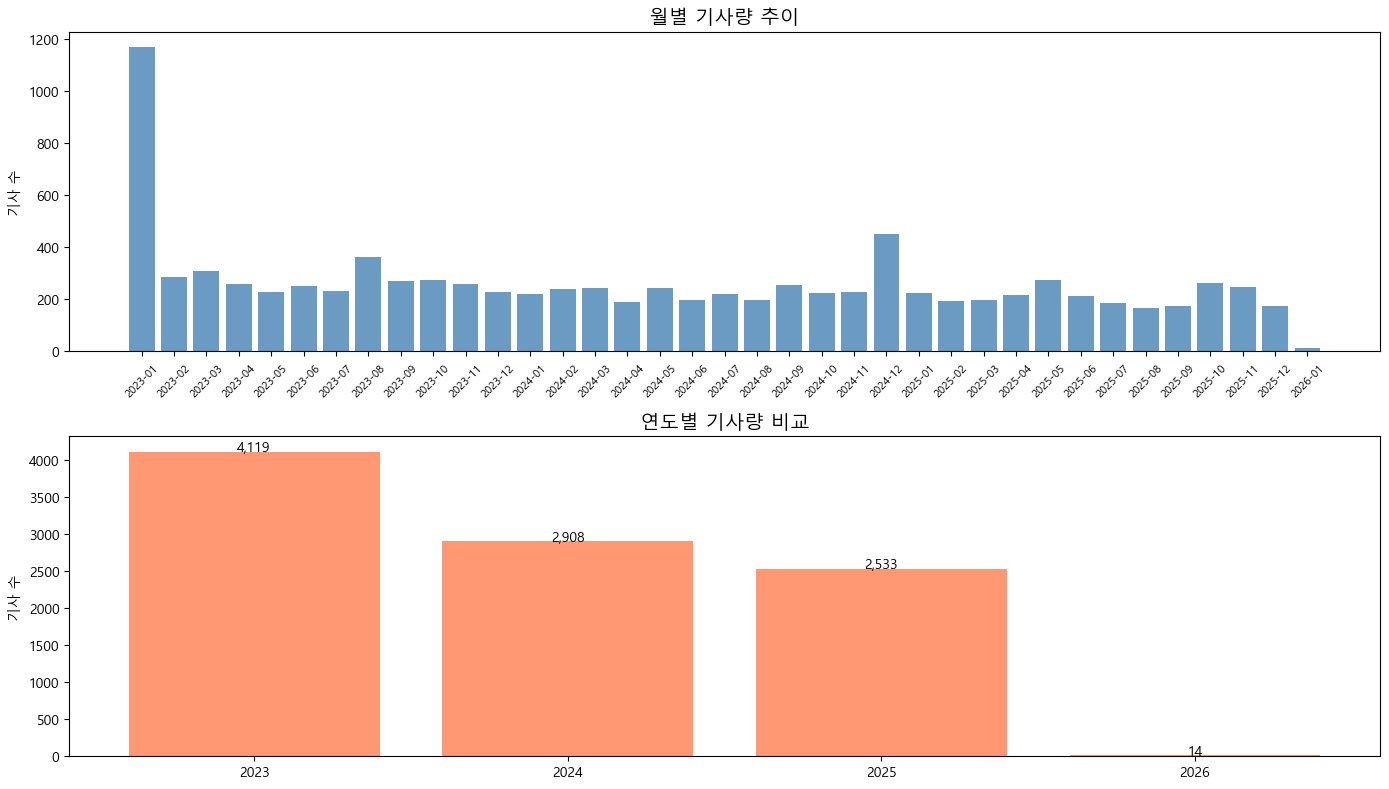

In [4]:
monthly = df.groupby("year_month").size().reset_index(name="count")
monthly["year_month_str"] = monthly["year_month"].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 월별 기사량 추이
axes[0].bar(monthly["year_month_str"], monthly["count"], color="steelblue", alpha=0.8)
axes[0].set_title("월별 기사량 추이", fontsize=14)
axes[0].set_xlabel("")
axes[0].set_ylabel("기사 수")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)

# 연도별 기사량
yearly = df.groupby("year").size().reset_index(name="count")
axes[1].bar(yearly["year"].astype(str), yearly["count"], color="coral", alpha=0.8)
axes[1].set_title("연도별 기사량 비교", fontsize=14)
axes[1].set_ylabel("기사 수")
for i, row in yearly.iterrows():
    axes[1].text(i, row["count"] + 10, f"{row['count']:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Step 3 — 키워드 빈도 분석

In [5]:
from kiwipiepy import Kiwi
from tqdm.auto import tqdm
tqdm.pandas()

kiwi = Kiwi()

STOPWORDS = {
    "성남", "성남시", "기자", "뉴스", "연합", "경기", "뉴시스",
    "머니투데이", "이데일리", "헤럴드", "조선", "중앙", "동아",
    "것", "수", "등", "년", "월", "일", "위해", "통해", "대해",
}

def extract_nouns(text: str) -> list[str]:
    if not isinstance(text, str) or not text.strip():
        return []
    tokens = kiwi.tokenize(text)
    return [
        t.form for t in tokens
        if t.tag.startswith("NN") and len(t.form) > 1 and t.form not in STOPWORDS
    ]

df["nouns"] = df["title"].progress_apply(extract_nouns)
print("명사 추출 완료")

  0%|          | 0/9574 [00:00<?, ?it/s]

명사 추출 완료


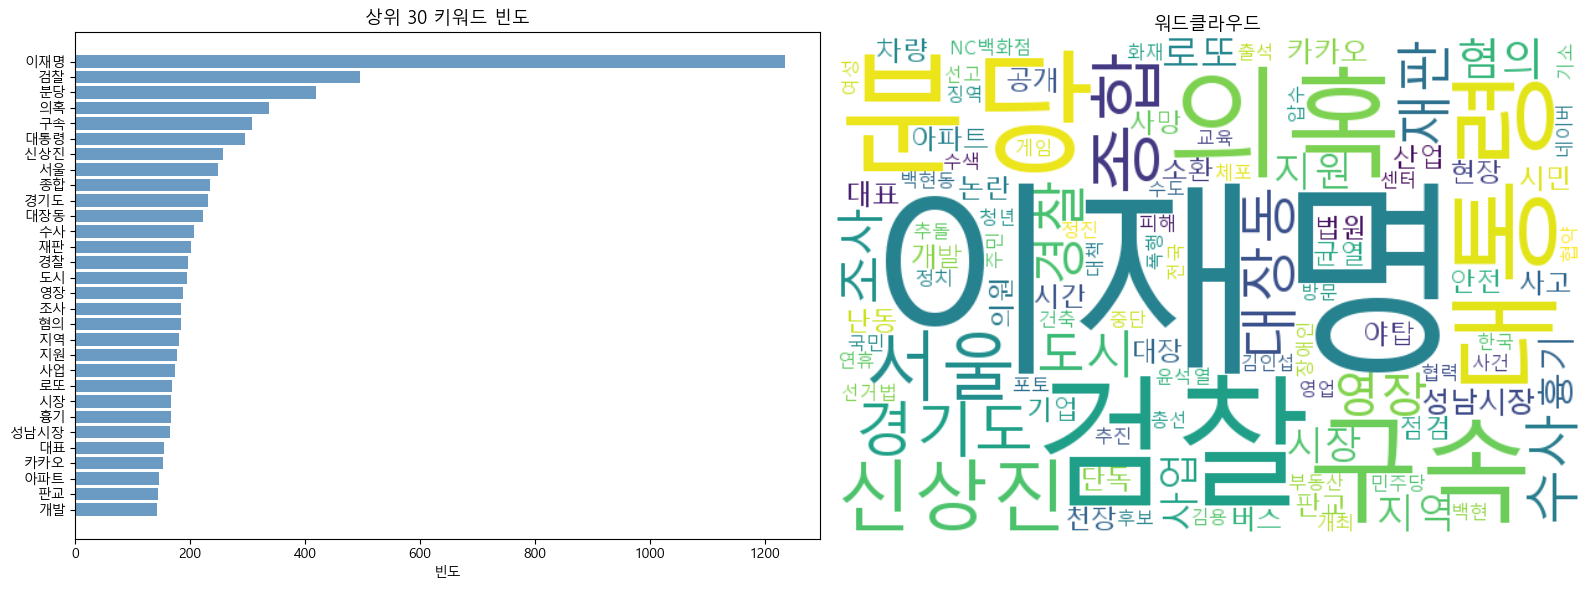

,word,count
0,이재명,1235
1,검찰,496
2,분당,419
3,의혹,338
4,구속,308
5,대통령,295
6,신상진,257
7,서울,249
8,종합,235
9,경기도,231


In [6]:
from collections import Counter

all_nouns = [noun for nouns in df["nouns"] for noun in nouns]
noun_freq = Counter(all_nouns)
top_nouns = pd.DataFrame(noun_freq.most_common(30), columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 바차트 (Top 30)
axes[0].barh(top_nouns["word"][::-1], top_nouns["count"][::-1], color="steelblue", alpha=0.8)
axes[0].set_title("상위 30 키워드 빈도", fontsize=13)
axes[0].set_xlabel("빈도")

# 워드클라우드
wc = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf",
    background_color="white",
    width=600,
    height=400,
    max_words=100,
).generate_from_frequencies(noun_freq)
axes[1].imshow(wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("워드클라우드", fontsize=13)

plt.tight_layout()
plt.show()
top_nouns

## Step 4 — 토픽 모델링 (BERTopic)

In [36]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN
from umap import UMAP

NGRAM_RANGE = (1, 2)

embedding_model = SentenceTransformer("jhgan/ko-sroberta-multitask")

umap_model = UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

vectorizer = CountVectorizer(ngram_range=NGRAM_RANGE)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=True),
    nr_topics=20,
    language="korean",
    verbose=True,
)

df["nouns_text"] = df["nouns"].apply(lambda x: " ".join(x))
docs = df["nouns_text"].tolist()

topics, probs = topic_model.fit_transform(docs)
df["topic_id"] = topics

print(f"N-gram 설정: {NGRAM_RANGE}")
print(f"유효 토픽 수: {len(set(topics)) - (1 if -1 in topics else 0)}개")
print(f"노이즈(-1) 비율: {(pd.Series(topics) == -1).mean():.1%}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-07 10:45:54,560 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/300 [00:00<?, ?it/s]

2026-04-07 10:46:29,566 - BERTopic - Embedding - Completed ✓
2026-04-07 10:46:29,566 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-07 10:46:38,096 - BERTopic - Dimensionality - Completed ✓
2026-04-07 10:46:38,097 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-07 10:46:38,281 - BERTopic - Cluster - Completed ✓
2026-04-07 10:46:38,282 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-07 10:46:38,484 - BERTopic - Representation - Completed ✓
2026-04-07 10:46:38,486 - BERTopic - Topic reduction - Reducing number of topics
2026-04-07 10:46:38,493 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-07 10:46:38,676 - BERTopic - Representation - Completed ✓
2026-04-07 10:46:38,678 - BERTopic - Topic reduction - Reduced number of topics from 92 to 20


N-gram 설정: (1, 2)
유효 토픽 수: 19개
노이즈(-1) 비율: 28.8%


In [39]:
# 토픽별 대표 키워드 및 기사 수 확인
topic_info = topic_model.get_topic_info()
topic_info_filtered = topic_info[topic_info["Topic"] != -1].reset_index(drop=True)
print(f"유효 토픽 수: {len(topic_info_filtered)}개\n")
topic_info_filtered[["Topic", "Count", "Name"]]

유효 토픽 수: 19개



,Topic,Count,Name
0,0,1625,0_이재명_검찰_재판_대장동
1,1,993,1_신상진_성남시장_신상진 성남시장_도시
2,2,655,2_반도체_청년_지원_장애인
3,3,547,3_흉기_난동_흉기 난동_폭행
4,4,496,4_게임_횡령_횡령 배임_카카오게임즈
5,5,484,5_천장_균열_천장 균열_야탑
6,6,364,6_연휴_교통_귀성_폭염
7,7,279,7_대통령_윤석열 대통령_귀국_공군
8,8,257,8_버스_추돌_돌진_음주
9,9,241,9_카카오_네이버_노조_카카오 노조


In [38]:
# 각 토픽 대표 기사 3건 출력
for _, row in topic_info_filtered.iterrows():
    topic_id = row["Topic"]
    topic_articles = df[df["topic_id"] == topic_id]["title"].head(3).tolist()
    print(f"\n[토픽 {topic_id}] {row['Name']}")
    for a in topic_articles:
        print(f"  - {a}")


[토픽 0] 0_이재명_검찰_재판_대장동
  - 권성동·윤상현·안철수·나경원 대구 집결…TK 표심 공략
  - 검찰, 이재명 법리검토 고심..불구속 기소 가능성도
  - 이재명, 측근에 털어놓은 진짜 고민은?

[토픽 1] 1_신상진_성남시장_신상진 성남시장_도시
  - "집값 못 잡는다고 정권 바꿔놓더니"…쌓였던 부동산 분노 폭발했다
  - 집값 낙폭 커지자 연착륙 총력…분상제 지역도 대거 축소할 듯
  - 신상진성남시장 "준예산 사태, 민생 포기한 직무유기"

[토픽 2] 2_반도체_청년_지원_장애인
  - [CSI] 취업 한파에 MZ 노점상 느는데…지자체 지원 '뒷걸음'
  - 성남시의료원, 시무식 개최…“내외부적 여러 논란에 방황하지말자”
  - 'HD현대' 새 이름으로…미래 해양사업에 중점

[토픽 3] 3_흉기_난동_흉기 난동_폭행
  - 반찬 투정한다고…새해 첫날 부친 때려 숨지게한 30대 지적장애인
  - "왜 반찬 투정해" 60대 아버지 폭행해 숨지게 한 30대 체포
  - 할머니한테 반찬투정 했다고..친부 폭행한 30대 체포

[토픽 4] 4_게임_횡령_횡령 배임_카카오게임즈
  - [단독]"왜 이리 안 뽑혀?"...넥슨 '확률형아이템 조작' 제재 착수
  - [수도권 주요 뉴스]연천·김포 산란계 농장서 AI 항원 검출
  - '최대 규모' 설 대책…21만t 성수품 공급·300억 할인 지원

[토픽 5] 5_천장_균열_천장 균열_야탑
  - 분당 10층짜리 빌딩 3층 화단 불…110여명 대피 소동
  - 경찰, 제2경인 방음터널 화재 관리사·시공사 관계자 소환
  - 또 무너진 안전…화성시 공사장서 철근 무너져 3명 사상

[토픽 6] 6_연휴_교통_귀성_폭염
  - 오늘도 매서운 추위…오후 들어 국외 미세먼지 유입
  - 겨울비에 울상이 된 축제장...얼음판 사수 '비상'
  - 성남시설 연휴 '7개 분야 27개 대책반 편성' 운영

[토픽 7] 7_대통령_윤석열 대통령_귀국_공군
  - 성남시대표단, 북미지역 방문…어떤 보따리 풀까
  

In [40]:
# 토픽 클러스터 시각화 (인터랙티브)
fig = topic_model.visualize_topics()
fig.show()


In [41]:
# 토픽별 문서 산포도 (UMAP 2D 임베딩)
fig = topic_model.visualize_documents(
    docs,
    topics=topics,
    hide_annotations=False,
    hide_document_hover=False,
)
fig.show()


In [42]:
# 토픽별 키워드 바차트
fig = topic_model.visualize_barchart(top_n_topics=15, n_words=8)
fig.show()


In [43]:
# 토픽 계층 구조 (덴드로그램)
fig = topic_model.visualize_hierarchy()
fig.show()


In [44]:
# 시계열 토픽 트렌드 (날짜 기반)
timestamps = df["date"].dt.to_pydatetime().tolist()
topics_over_time = topic_model.topics_over_time(docs, timestamps, nr_bins=30)
fig = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)
fig.show()


30it [00:02, 12.37it/s]


In [45]:
# Topic 2 기사 추출
df_t2 = df[df["topic_id"] == 2].reset_index(drop=True)
print(f"Topic 2 기사 수: {len(df_t2):,}건")


Topic 2 기사 수: 655건


In [46]:
# 대표 키워드 확인
print(topic_model.get_topic(2))


[('반도체', np.float64(0.3309760413315682)), ('청년', np.float64(0.3206613105350673)), ('지원', np.float64(0.3125416579466104)), ('장애인', np.float64(0.31209468443210625)), ('산업', np.float64(0.3000258865162568)), ('병원', np.float64(0.28803535206072367)), ('의료', np.float64(0.28686975639823364)), ('청소년', np.float64(0.2808906433495095)), ('모집', np.float64(0.2602581822828478)), ('교육', np.float64(0.25758391305396333))]


In [30]:
# 기사 목록 확인
from itables import show
df_show = df_t2[["date", "title", "press", "link"]].copy()
df_show["link"] = df_show["link"].apply(lambda x: f'<a href="{x}" target="_blank">링크</a>')
show(df_show, escape=False)


Loading ITables v2.7.3 from the internet... (need help?)


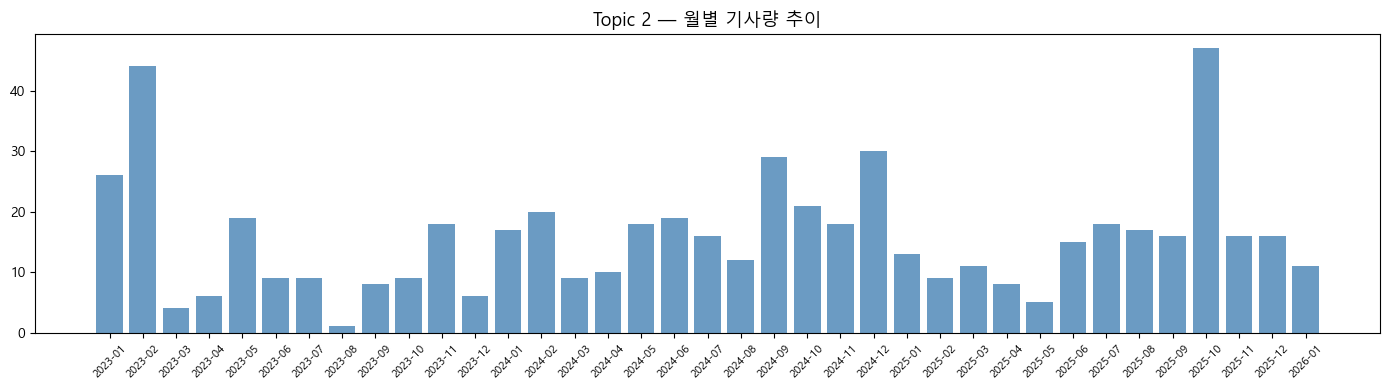

In [31]:
# 월별 기사량 추이
monthly_t2 = df_t2.groupby("year_month").size().reset_index(name="count")
monthly_t2["year_month_str"] = monthly_t2["year_month"].astype(str)

plt.figure(figsize=(14, 4))
plt.bar(monthly_t2["year_month_str"], monthly_t2["count"], color="steelblue", alpha=0.8)
plt.title("Topic 2 — 월별 기사량 추이", fontsize=13)
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()


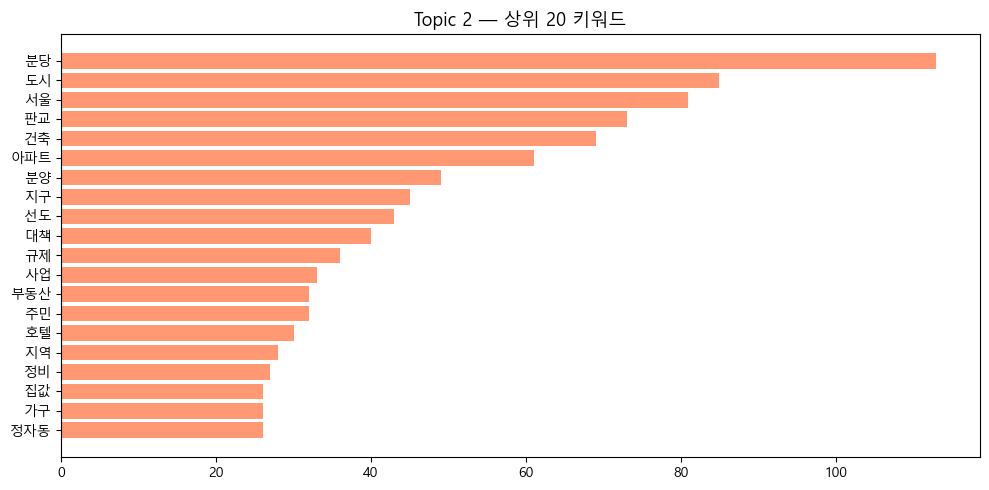

In [32]:
# Topic 2 키워드 빈도
all_nouns_t2 = [noun for nouns in df_t2["nouns"] for noun in nouns]
freq_t2 = Counter(all_nouns_t2)
top_t2 = pd.DataFrame(freq_t2.most_common(20), columns=["word", "count"])

plt.figure(figsize=(10, 5))
plt.barh(top_t2["word"][::-1], top_t2["count"][::-1], color="coral", alpha=0.8)
plt.title("Topic 2 — 상위 20 키워드", fontsize=13)
plt.tight_layout()
plt.show()


## Step 5 — 인사이트 요약

In [10]:
print("=" * 60)
print("PJ15 성남시 자영업 뉴스 분석 인사이트 요약")
print("=" * 60)

print(f"\n[수집 현황]")
print(f"  총 기사 수      : {len(df):,}건")
print(f"  수집 기간       : {df['date'].min().date()} ~ {df['date'].max().date()}")
print(f"  유효 토픽 수    : {len(topic_info_filtered)}개")
noise_ratio = (df["topic_id"] == -1).mean()
print(f"  노이즈 비율     : {noise_ratio:.1%}")

print(f"\n[상위 토픽 (기사 수 기준)]")
for _, row in topic_info_filtered.head(5).iterrows():
    print(f"  토픽 {row['Topic']:2d} | {row['Count']:4d}건 | {row['Name']}")

print(f"\n[상위 키워드 Top 10]")
for word, cnt in noun_freq.most_common(10):
    print(f"  {word}: {cnt:,}건")

peak_month = monthly.loc[monthly["count"].idxmax()]
print(f"\n[기사량 피크 월]")
print(f"  {peak_month['year_month_str']} — {peak_month['count']:,}건")

PJ15 성남시 자영업 뉴스 분석 인사이트 요약

[수집 현황]
  총 기사 수      : 9,574건
  수집 기간       : 2023-01-01 ~ 2026-01-01
  유효 토픽 수    : 19개
  노이즈 비율     : 29.2%

[상위 토픽 (기사 수 기준)]
  토픽  0 | 1896건 | 0_이재명_검찰_재판_대장동
  토픽  1 | 1169건 | 1_신상진_성남시장_경기도_지원
  토픽  2 |  580건 | 2_건축_분당_도시_판교
  토픽  3 |  513건 | 3_천장_야탑_균열_nc백화점
  토픽  4 |  433건 | 4_흉기_난동_여성_서현역

[상위 키워드 Top 10]
  이재명: 1,235건
  검찰: 496건
  분당: 419건
  의혹: 338건
  구속: 308건
  대통령: 295건
  신상진: 257건
  서울: 249건
  종합: 235건
  경기도: 231건

[기사량 피크 월]
  2023-01 — 1,169건


### 중간 결론
-  해당 기간 중 정치 사회 이슈가 과도해 성남시 키워드로 크롤링한 데이터를 통해 토픽 분류가 정상적으로 이뤄지지 않는다.
-  키워드를 변경해 새로 크롤링을 하거나, 다른 추가 데이터 접근 방식이 필요할 듯.